/tmp/ipykernel_58262/2233126037.py:19: RuntimeWarning: overflow encountered in exp
  e_x = np.exp(x - np.max(x))
/tmp/ipykernel_58262/2233126037.py:20: RuntimeWarning: invalid value encountered in divide
  return e_x / e_x.sum(axis=0)


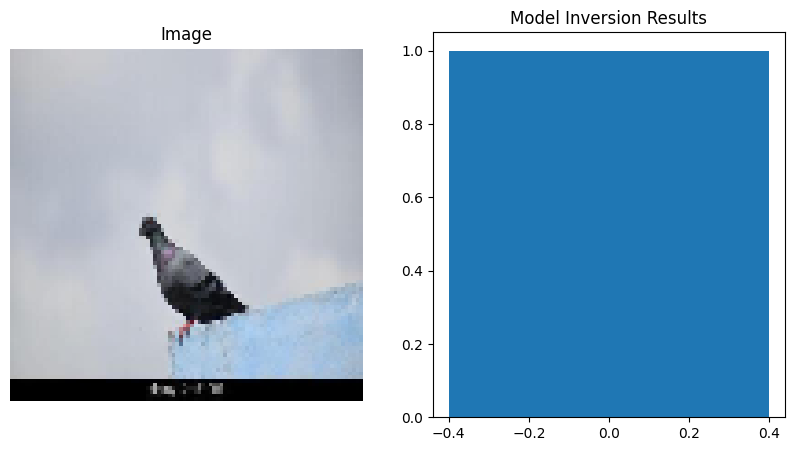

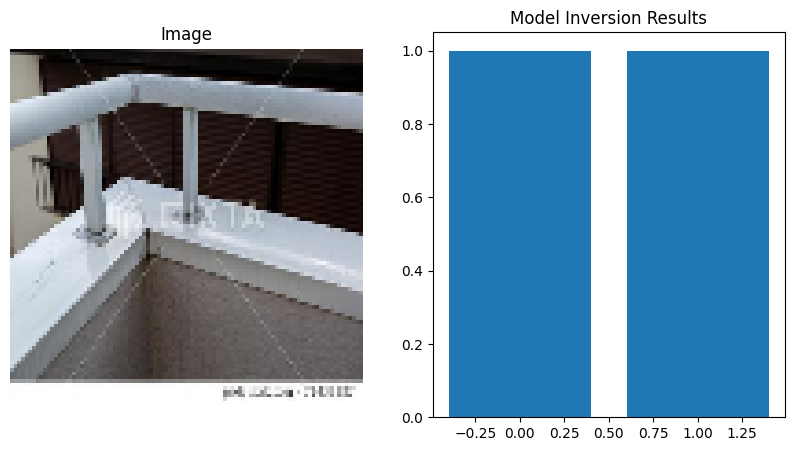

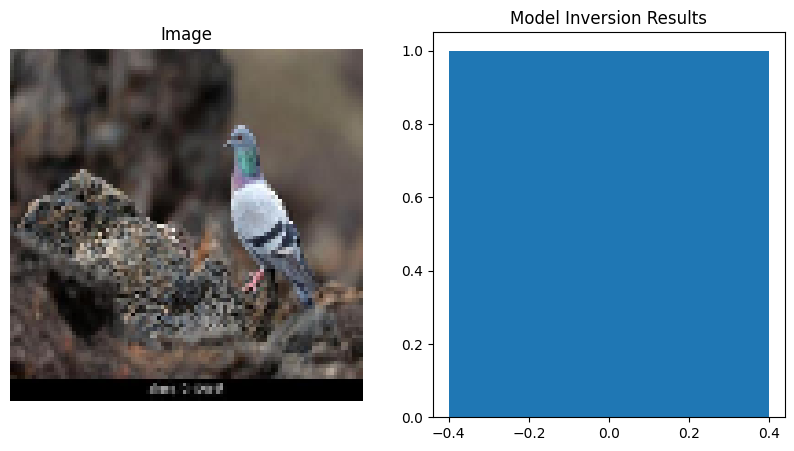

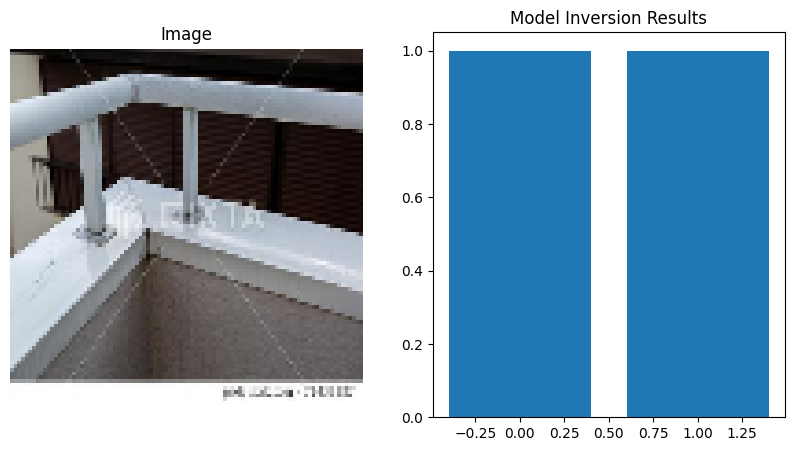

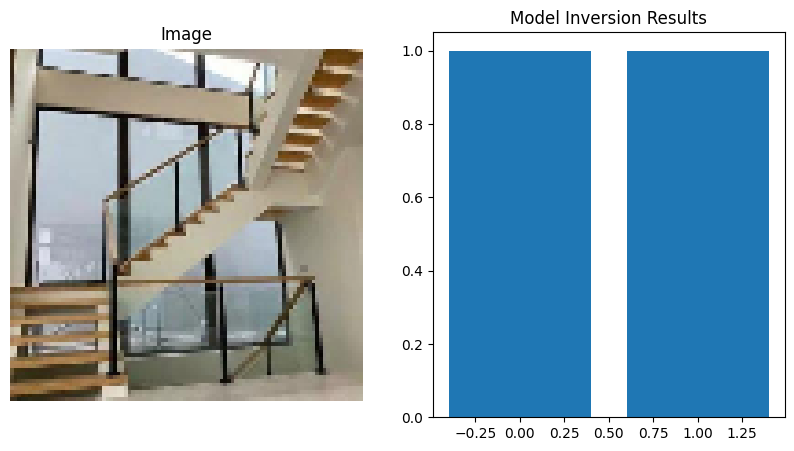

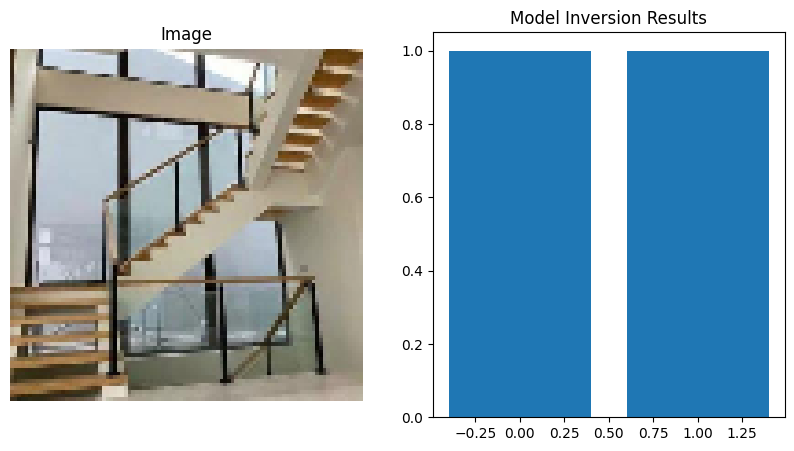

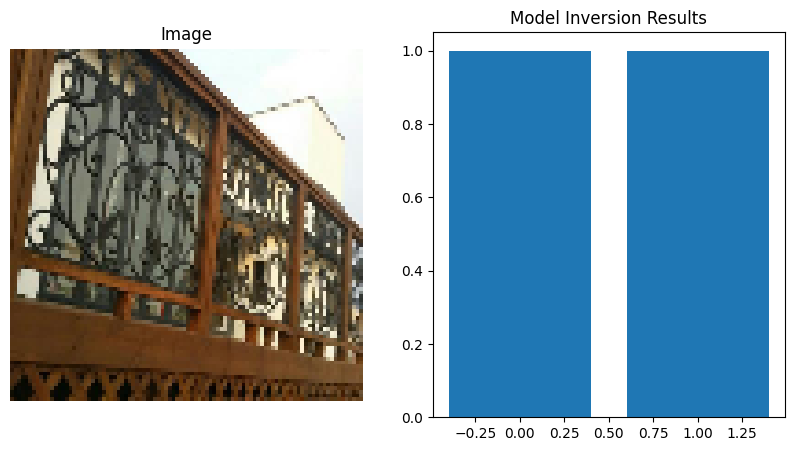

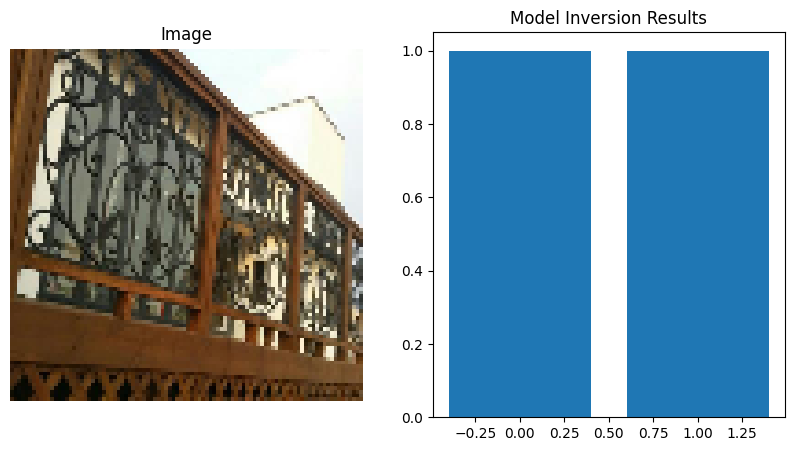

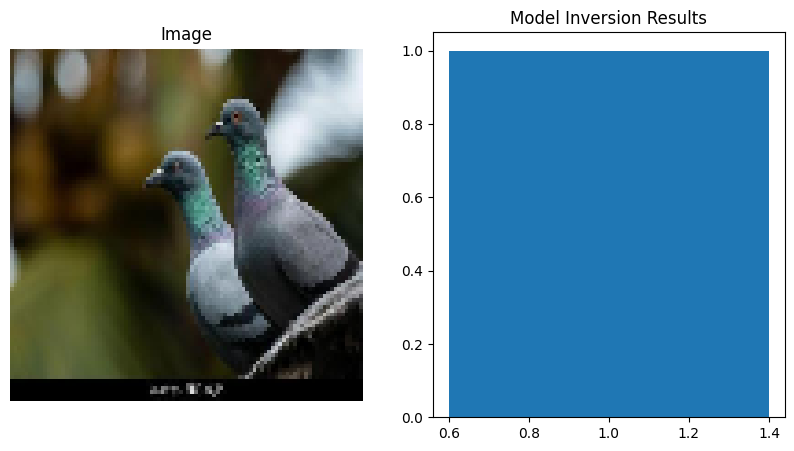

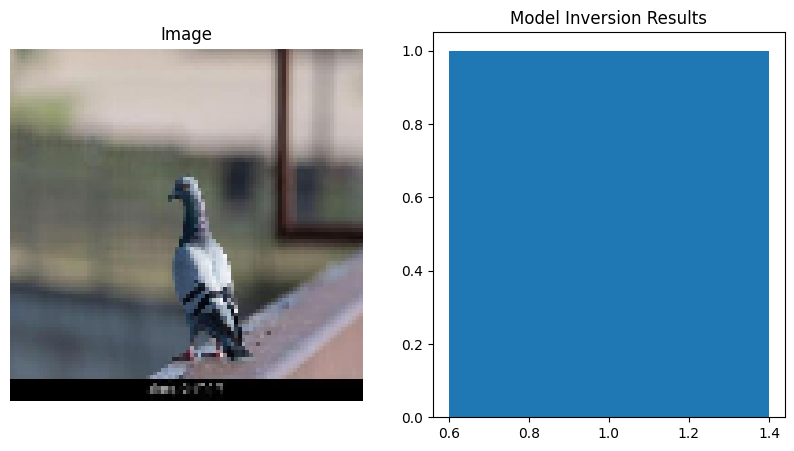

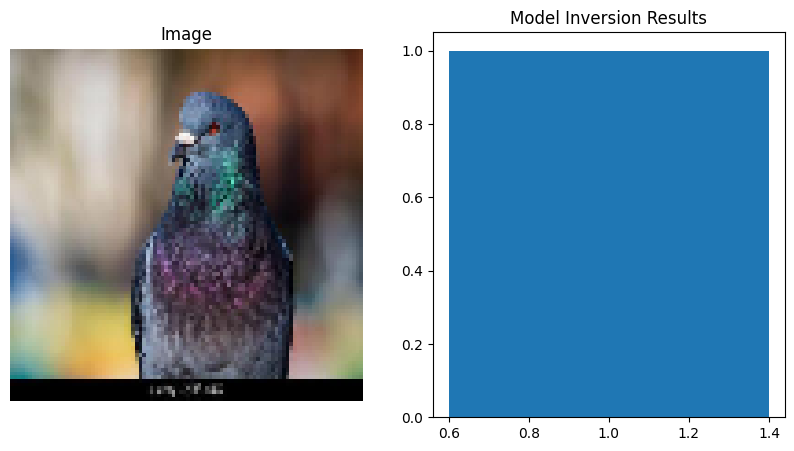

In [3]:
import numpy as np
import cv2
from PIL import Image
from tflite_runtime.interpreter import Interpreter
import os
import matplotlib.pyplot as plt

# Load TFLite model and allocate tensors
interpreter = Interpreter(model_path="models/ei-birdwatch_01-transfer-learning-tensorflow-lite-int8-quantized-model.lite")
interpreter.allocate_tensors()

# Get input and output tensors
input_details = interpreter.get_input_details()
output_details = interpreter.get_output_details()
image_dir = 'datasets/pigeons_validation'

def softmax(x):
    """Compute softmax values for each sets of scores in x."""
    e_x = np.exp(x - np.max(x))
    return e_x / e_x.sum(axis=0)


def invert_model(image_path, interpreter, input_details, output_details):
    # Read the image using OpenCV
    image = cv2.imread(image_path)

    # Resize the image to 96x96
    image_resized = cv2.resize(image, (96, 96))

    # Convert the image to RGB
    image_rgb = cv2.cvtColor(image_resized, cv2.COLOR_BGR2RGB)

    # Convert the image to a numpy array and normalize it
    input_data = np.array(image_rgb, dtype=np.float32)

    # Scale the data back to the original range and convert to INT8
    input_data = np.round(input_data * 255).astype(np.int8)

    # Add a new dimension to match model's input shape
    input_data = np.expand_dims(input_data, axis=0)

    # Point the data to be used for testing and run the interpreter
    interpreter.set_tensor(input_details[0]['index'], input_data)
    interpreter.invoke()

    # Obtain results and print them
    output_data = interpreter.get_tensor(output_details[0]['index'])
    output_data = softmax(output_data)

    # Display the image and the results
    plt.figure(figsize=(10, 5))
    plt.subplot(1, 2, 1)
    plt.imshow(image_rgb)
    plt.title('Image')
    plt.axis('off')

    plt.subplot(1, 2, 2)
    plt.bar(range(len(output_data[0])), output_data[0])
    plt.title('Model Inversion Results')
    plt.show()


# Walk through the directory
for root, dirs, files in os.walk(image_dir):
    for file in files:
        # Check if the file is an image
        if file.endswith(('.png', '.jpg', '.jpeg')):
            image_path = os.path.join(root, file)

            # Run the interpreter and softmax
            invert_model(image_path, interpreter, input_details, output_details)
